<a href="https://colab.research.google.com/github/Jadhav-Suraj/Deep-Learning/blob/main/CNN(Ai_school).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
import tensorflow as ts
from tensorflow.keras.models import Sequential ## layer by layer neural network
from tensorflow.keras.layers import Dense ## Makes final prediction
from tensorflow.keras.layers import Conv2D ## extract features
from tensorflow.keras.layers import MaxPooling2D ## reduces size
from tensorflow.keras.layers import Flatten ## Single array conversion
from tensorflow.keras.layers import Dropout ## prevent overfitting
from tensorflow.keras.utils import to_categorical

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/mnist_train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/Dataset/mnist_test.csv')

In [ ]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

In [ ]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [ ]:
df.isnull().sum()

,0
label,0
1x1,0
1x2,0
1x3,0
1x4,0
...,...
28x24,0
28x25,0
28x26,0
28x27,0


In [ ]:
## Data Preprocessing

X_train = df.drop('label',axis=1).values
y_train = df['label'].values

In [ ]:
X_test = df.drop('label',axis=1).values
y_test = df['label'].values

In [ ]:
## feature scaling(Applying min-maxscaling) i.e. 0 to 1

X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

In [ ]:
## Reshape(For each image pixels at in one array)

X_train_img = X_train.reshape(-1,28,28)
X_test_img = X_test.reshape(-1,28,28)

In [ ]:
## Converting Output into One hot encoded format

y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [ ]:
## Creating Perceptron Model

perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')
])

In [ ]:
perceptron.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
## Trainning and fitting the data

history_percp = perceptron.fit(X_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8117 - loss: 0.7872 - val_accuracy: 0.8733 - val_loss: 0.5035
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8806 - loss: 0.4560 - val_accuracy: 0.8884 - val_loss: 0.4215
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8913 - loss: 0.4029 - val_accuracy: 0.8942 - val_loss: 0.3863
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8972 - loss: 0.3765 - val_accuracy: 0.9002 - val_loss: 0.3656
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9005 - loss: 0.3596 - val_accuracy: 0.9029 - val_loss: 0.3524


In [ ]:
acc_percp = perceptron.evaluate(X_test_img,y_test_cat,verbose=0)[1]


In [ ]:
print('Accuracy of Perceptron Model : ',acc_percp)

Accuracy of Perceptron Model :  0.902899980545044


In [ ]:
## Creating ANN Model

ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax")
])

In [ ]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
## Fitting nad training the data(ANN Model)

history_ann = ann.fit(X_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9255 - loss: 0.2489 - val_accuracy: 0.9664 - val_loss: 0.1110
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9680 - loss: 0.1044 - val_accuracy: 0.9797 - val_loss: 0.0667
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9768 - loss: 0.0732 - val_accuracy: 0.9841 - val_loss: 0.0511
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9832 - loss: 0.0540 - val_accuracy: 0.9883 - val_loss: 0.0379
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9859 - loss: 0.0424 - val_accuracy: 0.9914 - val_loss: 0.0279


In [ ]:
acc_ann = ann.evaluate(X_test_img, y_test_cat,verbose=0)[1]

In [ ]:
print('Accuracy of ANN Model : ',acc_ann)

Accuracy of ANN Model :  0.9913833141326904


In [ ]:
## Creating CNN Model

cnn = Sequential([
    Conv2D(32,kernel_size=(3,2),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,2),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

In [ ]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history_cnn = cnn.fit(X_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 40ms/step - accuracy: 0.9343 - loss: 0.2172 - val_accuracy: 0.9826 - val_loss: 0.0547
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 89s 44ms/step - accuracy: 0.9749 - loss: 0.0835 - val_accuracy: 0.9898 - val_loss: 0.0324
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 138s 42ms/step - accuracy: 0.9810 - loss: 0.0619 - val_accuracy: 0.9931 - val_loss: 0.0234
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.9850 - loss: 0.0501 - val_accuracy: 0.9940 - val_loss: 0.0191
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 46ms/step - accuracy: 0.9868 - loss: 0.0421 - val_accuracy: 0.9950 - val_loss: 0.0159


In [ ]:
acc_cnn = cnn.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [ ]:
print('Accuracy of CNN Model : ',acc_cnn)

Accuracy of CNN Model :  0.9949833154678345


### Plotting Training History

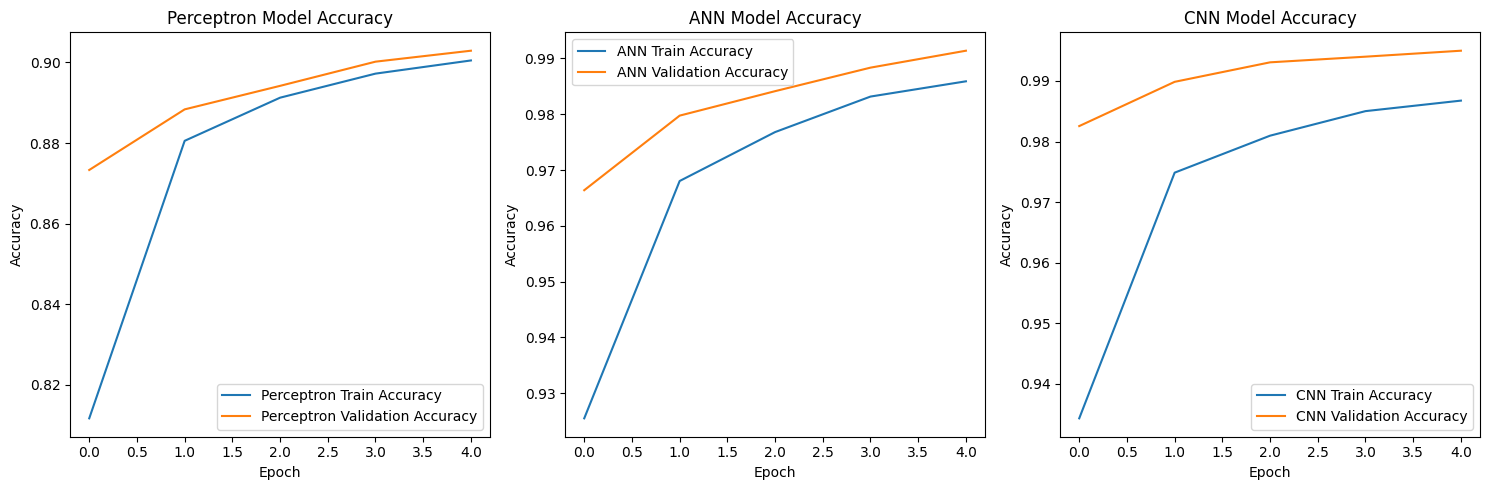

In [ ]:
plt.figure(figsize=(15, 5))

# Plot Perceptron History
plt.subplot(1, 3, 1)
plt.plot(history_percp.history['accuracy'], label='Perceptron Train Accuracy')
plt.plot(history_percp.history['val_accuracy'], label='Perceptron Validation Accuracy')
plt.title('Perceptron Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot ANN History
plt.subplot(1, 3, 2)
plt.plot(history_ann.history['accuracy'], label='ANN Train Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='ANN Validation Accuracy')
plt.title('ANN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot CNN History
plt.subplot(1, 3, 3)
plt.plot(history_cnn.history['accuracy'], label='CNN Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

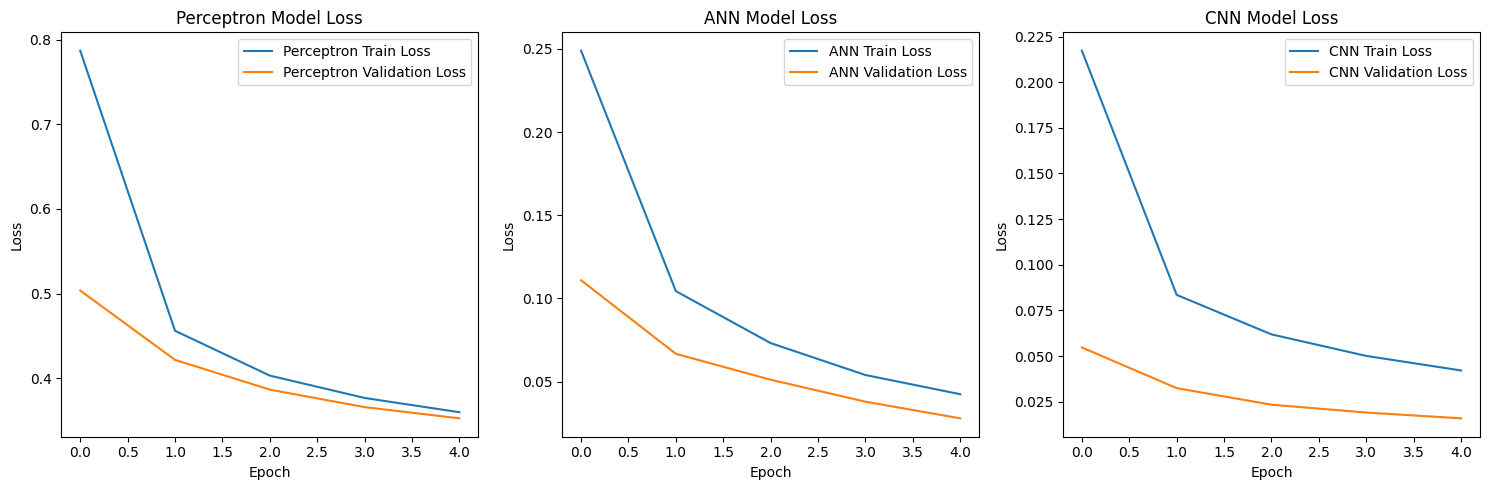

In [ ]:
plt.figure(figsize=(15, 5))

# Plot Perceptron History
plt.subplot(1, 3, 1)
plt.plot(history_percp.history['loss'], label='Perceptron Train Loss')
plt.plot(history_percp.history['val_loss'], label='Perceptron Validation Loss')
plt.title('Perceptron Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot ANN History
plt.subplot(1, 3, 2)
plt.plot(history_ann.history['loss'], label='ANN Train Loss')
plt.plot(history_ann.history['val_loss'], label='ANN Validation Loss')
plt.title('ANN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot CNN History
plt.subplot(1, 3, 3)
plt.plot(history_cnn.history['loss'], label='CNN Train Loss')
plt.plot(history_cnn.history['val_loss'], label='CNN Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Comparing Final Model Accuracies

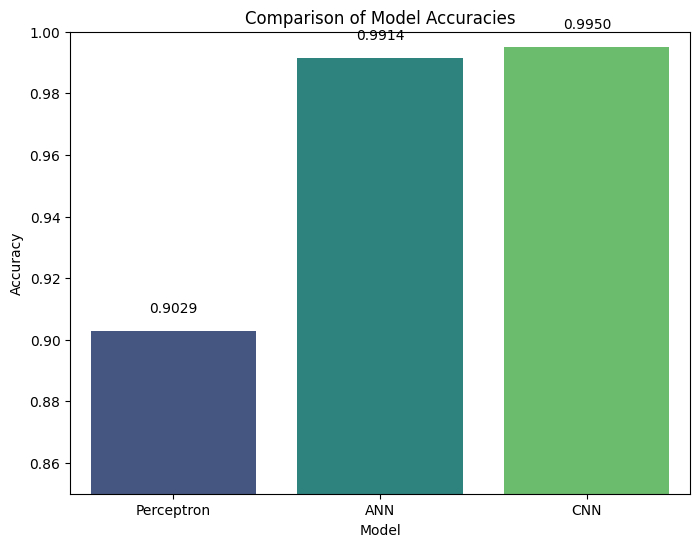

In [ ]:
model_names = ['Perceptron', 'ANN', 'CNN']
accuracies = [acc_percp, acc_ann, acc_cnn]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.85, 1.0) # Set y-axis limits to better visualize differences

# Add accuracy values on top of bars
for index, value in enumerate(accuracies):
    plt.text(index, value + 0.005, f'{value:.4f}', ha='center', va='bottom')

plt.show()